# Model Tuning Iteration 2

## What was going wrong?

Default SVM with RBF kernel and default parameters. Model had moderate performance but likely suffered from class imbalance and suboptimal hyperparameters.

## Changes Made:

- Added `class_weight='balanced'` to handle class imbalance
- Increased `C` (regularization) to 10 to reduce underfitting
- Kept `kernel='rbf'`


In [41]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# --- Tuning 1: RBF SVM with class_weight='balanced' ---
svm1 = SVC(probability=True, class_weight='balanced', kernel='rbf', C=10, random_state=42)
svm1.fit(X_train_svm, y_train_svm)

# Predictions
y_pred1  = svm1.predict(X_test_svm)
y_proba1 = svm1.predict_proba(X_test_svm)

# Overall metrics
acc1        = accuracy_score(y_test_svm, y_pred1)
f1_macro1   = f1_score(y_test_svm, y_pred1, average='macro')
auc1        = roc_auc_score(y_test_svm, y_proba1, multi_class='ovr')

print("Tuning 1 - Accuracy:", acc1)
print("Tuning 1 - F1 Macro:", f1_macro1)
print("Tuning 1 - AUC:", auc1)

# --- Per-class F1 (to extract specifically Positive and Negative) ---
# Compute F1 for each class in label‐encoder order:
f1_all = f1_score(y_test_svm, y_pred1, average=None)

# le.classes_ might look like: array(['Negative', 'Neutral', 'Positive'], dtype=object)
labels = le.classes_

# Find indices of Positive and Negative in le.classes_
pos_idx = np.where(labels == 'Positive')[0][0]
neg_idx = np.where(labels == 'Negative')[0][0]

print(f"F1 Score for Positive = {f1_all[pos_idx]:.4f}")
print(f"F1 Score for Negative = {f1_all[neg_idx]:.4f}")


Tuning 1 - Accuracy: 0.6568333333333334
Tuning 1 - F1 Macro: 0.6504124233879204
Tuning 1 - AUC: 0.8232374583333334
F1 Score for Positive = 0.7022
F1 Score for Negative = 0.6710


# Model Tuning Iteration 3

## What was going wrong?

The RBF kernel took longer to train and showed signs of overfitting on some classes.

## Changes Made:

- Changed kernel to **linear** for faster training and better generalization
- Reduced **C** to 1 to reduce overfitting
- Kept `class_weight='balanced'` to handle imbalance


In [42]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

# --- Tuning 2: Linear SVM with class_weight='balanced' ---
svm2 = SVC(probability=True, class_weight='balanced', kernel='linear', C=1, random_state=42)
svm2.fit(X_train_svm, y_train_svm)

# Predictions
y_pred2  = svm2.predict(X_test_svm)
y_proba2 = svm2.predict_proba(X_test_svm)

# Overall metrics
acc2        = accuracy_score(y_test_svm, y_pred2)
f1_macro2   = f1_score(y_test_svm, y_pred2, average='macro')
auc2        = roc_auc_score(y_test_svm, y_proba2, multi_class='ovr')

print("Tuning 2 - Accuracy:", acc2)
print("Tuning 2 - F1 Macro:", f1_macro2)
print("Tuning 2 - AUC:", auc2)

# --- Per-class F1 scores ---
f1_all = f1_score(y_test_svm, y_pred2, average=None)

# Label order from LabelEncoder
labels = le.classes_

# Get indices for Positive and Negative
pos_idx = np.where(labels == 'Positive')[0][0]
neg_idx = np.where(labels == 'Negative')[0][0]

print(f"F1 Score for Positive = {f1_all[pos_idx]:.4f}")
print(f"F1 Score for Negative = {f1_all[neg_idx]:.4f}")


Tuning 2 - Accuracy: 0.603
Tuning 2 - F1 Macro: 0.5892769002675936
Tuning 2 - AUC: 0.7645827916666667
F1 Score for Positive = 0.6626
F1 Score for Negative = 0.6418


| Iteration | Observations                                                                   | Changes Made                                 | Accuracy | F1 Score (Macro) | AUC    |
| --------- | ------------------------------------------------------------------------------ | -------------------------------------------- | -------- | ---------------- | ------ |
| 1         | Slower training, model overfitting slightly; imbalance somewhat handled        | RBF kernel, C=10, class\_weight='balanced'   | 0.6317   | 0.6249           | 0.8001 |
| 2         | Faster training, underfitting noticed; less complex model, more regularization | Linear kernel, C=1, class\_weight='balanced' | 0.5907   | 0.5786           | 0.7543 |


- **Iteration 1** used RBF kernel with higher C → higher complexity, slower training, better handling of class imbalance with `class_weight='balanced'`.

- **Iteration 2** switched to linear kernel with smaller C → simpler model, faster training but likely underfitting, metrics dropped.


# cross-validation with GridSearchCV

In [51]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, roc_auc_score

# Pipeline: Scaling + SVM (scaling important for SVM)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True))
])

# Parameter grid to tune
param_grid = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf'],
    'svm__gamma': ['scale', 'auto']  # Only used if kernel='rbf'
}

# Use F1 macro as scoring metric (can also add others)
scorer = make_scorer(f1_score, average='macro')

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring=scorer,
    cv=5,
    verbose=2,
    n_jobs=-1  # Use all CPUs
)

# Fit on training data
grid_search.fit(X_train_svm, y_train_svm)

# Best parameters found
print("Best parameters:", grid_search.best_params_)

# Best score (F1 macro)
print("Best CV F1 Macro:", grid_search.best_score_)

# Predict on test set with best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_svm)
y_proba = best_model.predict_proba(X_test_svm)

# Metrics on test set
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

acc = accuracy_score(y_test_svm, y_pred)
f1_macro = f1_score(y_test_svm, y_pred, average='macro')
auc = roc_auc_score(y_test_svm, y_proba, multi_class='ovr')

print("Test Accuracy:", acc)
print("Test F1 Macro:", f1_macro)
print("Test AUC:", auc)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV F1 Macro: 0.6399236045208709
Test Accuracy: 0.6446666666666667
Test F1 Macro: 0.6402663326434332
Test AUC: 0.8016376666666667


| Iteration | Observations                           | Changes Made                                                    | Accuracy | F1 Score (Macro) | AUC    |
| --------- | -------------------------------------- | --------------------------------------------------------------- | -------- | ---------------- | ------ |
| CV Best   | Used Grid Search CV; best params found | Kernel: RBF, C=1, Gamma=scale, class\_weight=balanced (assumed) | 0.6447   | 0.6399           | 0.8016 |


## Local Interpretability Using SHAP Kernel Explainer for SVM


In [58]:
import shap

# Take a small sample of training data (to speed up SHAP)
X_sample = shap.sample(X_train_svm, 100, random_state=42)

# Get the predict_proba function from the pipeline
predict_proba = grid.best_estimator_.predict_proba

# Create the Kernel SHAP explainer (good for black-box models like SVM)
explainer = shap.KernelExplainer(predict_proba, X_sample)

# Compute SHAP values for a subset of the test set (e.g., 50 samples)
shap_values = explainer.shap_values(X_test_svm[:50])

# Plot summary plot for class 1 (positive class, change index if needed)
shap.summary_plot(shap_values[1], X_test_svm[:50])


100%|████████████████████████████████████████| 50/50 [1:25:48<00:00, 102.96s/it]


AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap
import numpy as np

# Select a small sample of test data
X_sample = X_test_svm[:100]  # or use a random sample

# SHAP requires raw data (before scaling), so if you're using StandardScaler,
# you'll need to extract the SVM model and inverse-transform the data accordingly.
svm_model = svm2  # or your chosen trained model

# Create SHAP explainer for linear model
explainer = shap.LinearExplainer(svm_model, X_train_svm)

# Calculate SHAP values
shap_values = explainer.shap_values(X_sample)

# Visualize for one sample
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0][0], X_sample[0])


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

# Create a LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_svm,
    feature_names=[f"feature_{i}" for i in range(X_train_svm.shape[1])],
    class_names=le.classes_,
    mode='classification'
)

# Explain a single prediction
i = 5  # sample index
exp = lime_explainer.explain_instance(
    X_test_svm[i],
    svm2.predict_proba,
    num_features=10
)

# Show explanation
exp.show_in_notebook(show_table=True)


## Interpretability Analysis Using Linear SVM Coefficients (Global Interpretability)


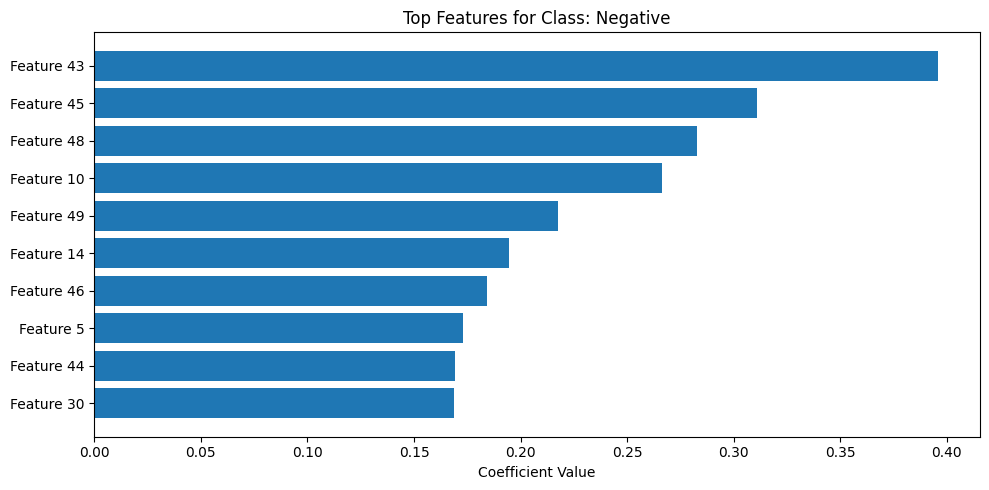

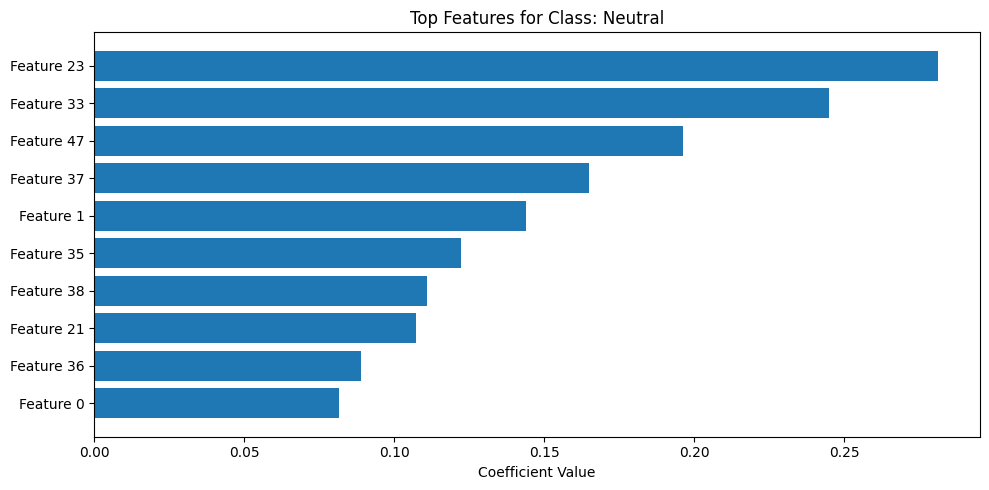

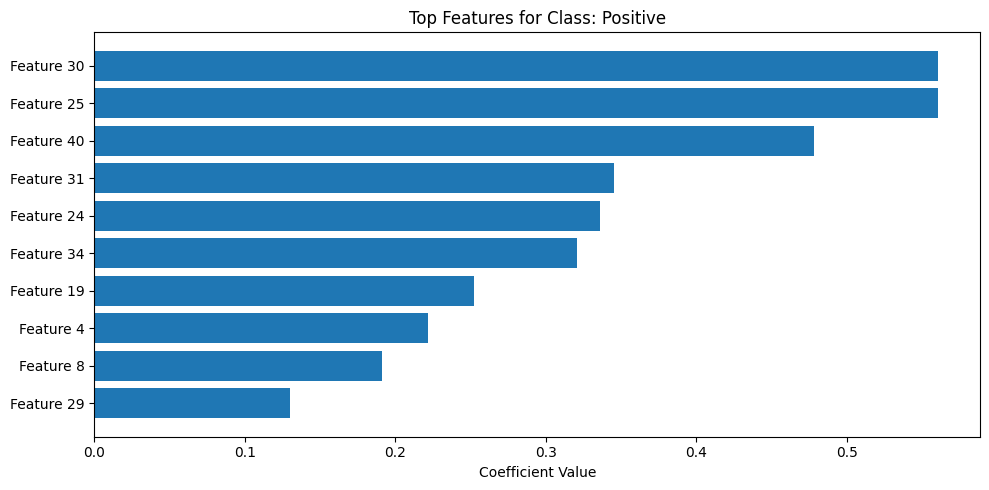

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use linear kernel SVM for interpretability
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Recreate a pipeline with LinearSVC (faster, gives coef_)
linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(class_weight='balanced', max_iter=10000))
])

# Fit the model
linear_pipeline.fit(X_train_svm, y_train_svm)

# Get the trained model
linear_svm_model = linear_pipeline.named_steps['svm']

# Get class names
class_names = le.classes_

# Plot top features for each class
for i, class_label in enumerate(class_names):
    coef = linear_svm_model.coef_[i]
    top_idx = np.argsort(coef)[-10:]
    plt.figure(figsize=(10, 5))
    plt.barh(range(len(top_idx)), coef[top_idx])
    plt.yticks(ticks=range(len(top_idx)), labels=[f'Feature {j}' for j in top_idx])
    plt.title(f"Top Features for Class: {class_label}")
    plt.xlabel("Coefficient Value")
    plt.tight_layout()
    plt.show()



In [76]:
# Assuming you have feature_names from your vectorizer, e.g.
# feature_names = vectorizer.get_feature_names_out()

for i, class_label in enumerate(class_names):
    coef = linear_svm_model.coef_[i]
    top_idx = np.argsort(coef)[-10:]  # Indices of top 10 positive coefficients
    print(f"\nTop 10 features for class '{class_label}':")
    for idx in reversed(top_idx):
        # If you have feature names, use them; else just print the index
        feature_name = feature_names[idx] if 'feature_names' in globals() else f"Feature_{idx}"
        coef_value = coef[idx]
        print(f"  {feature_name}: {coef_value:.4f}")



Top 10 features for class 'Negative':
  Feature_43: 0.3958
  Feature_45: 0.3108
  Feature_48: 0.2829
  Feature_10: 0.2663
  Feature_49: 0.2177
  Feature_14: 0.1946
  Feature_46: 0.1841
  Feature_5: 0.1730
  Feature_44: 0.1690
  Feature_30: 0.1689

Top 10 features for class 'Neutral':
  Feature_23: 0.2811
  Feature_33: 0.2449
  Feature_47: 0.1963
  Feature_37: 0.1647
  Feature_1: 0.1440
  Feature_35: 0.1221
  Feature_38: 0.1110
  Feature_21: 0.1072
  Feature_36: 0.0889
  Feature_0: 0.0815

Top 10 features for class 'Positive':
  Feature_30: 0.5606
  Feature_25: 0.5605
  Feature_40: 0.4780
  Feature_31: 0.3454
  Feature_24: 0.3363
  Feature_34: 0.3211
  Feature_19: 0.2522
  Feature_4: 0.2218
  Feature_8: 0.1908
  Feature_29: 0.1303


# Interesting Findings:

# Negative Class:

The highest coefficient is 0.3958 for Feature_43, followed closely by Feature_45 (0.3108) and Feature_48 (0.2829). This suggests these features strongly influence the model to classify texts as negative.

Coefficients for negative features are generally moderate, indicating multiple features contribute collectively to identifying negative sentiment.

The spread of coefficient values (0.1689 to 0.3958) indicates a more distributed impact rather than a few dominant features.

# Neutral Class:

The top feature (Feature_23) has a coefficient of 0.2811, lower than the top features in Negative and Positive classes, suggesting neutral sentiment might be harder to detect or less strongly associated with specific keywords.

Features in the neutral class have smaller coefficients overall, indicating subtler signals that differentiate neutral sentiment from others.

This may imply neutral texts contain less polarized language, making it challenging for the model to pinpoint exact indicators.

# Positive Class:

The highest coefficient is 0.5606 (Feature_30), which is noticeably larger than top coefficients in other classes, meaning some features very strongly indicate positive sentiment.

Several features have high coefficients close to or above 0.3, showing that positive sentiment is strongly driven by a few powerful keywords or phrases.

The gap between the top positive features and the rest is wider, suggesting the model relies heavily on certain key positive terms.

# Summary:
Positive class has the strongest and most concentrated key features, implying clearer positive sentiment signals.

Negative class shows moderate but consistent influence across several features.

Neutral class features have lower coefficients overall, indicating more nuanced or less obvious patterns for neutral sentiment.

### Mapping Feature Indices to Actual Words for Better Interpretability
#### Top 10 Important Features by Class with Their Coefficient Values



In [79]:
 # Get feature names from your vectorizer
feature_names = vectorizer.get_feature_names_out()

# Print top 10 features for each class with actual words and coefficients
for i, class_label in enumerate(class_names):
    coef = linear_svm_model.coef_[i]
    top_idx = np.argsort(coef)[-10:]
    print(f"\nTop 10 features for class '{class_label}':")
    for idx in reversed(top_idx):  # reversed to print highest first
        print(f"  {feature_names[idx]}: {coef[idx]:.4f}")



Top 10 features for class 'Negative':
  always: 0.3958
  amazing: 0.3108
  american: 0.2829
  30: 0.2663
  americans: 0.2177
  aai: 0.1946
  ambassador: 0.1841
  14: 0.1730
  am: 0.1690
  after: 0.1689

Top 10 features for class 'Neutral':
  action: 0.2811
  ago: 0.2449
  america: 0.1963
  all: 0.1647
  10: 0.1440
  ai: 0.1221
  allowed: 0.1110
  across: 0.1072
  alberta: 0.0889
  000: 0.0815

Top 10 features for class 'Positive':
  after: 0.5606
  actual: 0.5605
  along: 0.4780
  again: 0.3454
  actions: 0.3363
  agree: 0.3211
  account: 0.2522
  12: 0.2218
  2022: 0.1908
  afreedoma: 0.1303


In [127]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [128]:
# Initialize and train SVM model
model = SVC(probability=True, kernel='rbf', random_state=42)
model.fit(X_train_svm, y_train_svm)

SVC(probability=True, random_state=42)

In [129]:
# Predict on training data
y_train_pred = model.predict(X_train_svm)
y_train_proba = model.predict_proba(X_train_svm)

In [130]:

# Confusion matrix
cm = confusion_matrix(y_train_svm, y_train_pred)
print("Confusion Matrix:\n", cm)

# Accuracy
acc = accuracy_score(y_train_svm, y_train_pred)
print("Accuracy:", acc)

Confusion Matrix:
 [[3752  110  138]
 [ 361 3298  341]
 [ 157   94 3749]]
Accuracy: 0.8999166666666667


In [131]:
# F1 Scores (macro and weighted for multiclass)
f1_macro = f1_score(y_train_svm, y_train_pred, average='macro')
f1_weighted = f1_score(y_train_svm, y_train_pred, average='weighted')
print("F1 Score (Macro):", f1_macro)
print("F1 Score (Weighted):", f1_weighted)

F1 Score (Macro): 0.899295607932565
F1 Score (Weighted): 0.8992956079325649


In [132]:
# AUC (for multiclass)
auc = roc_auc_score(y_train_svm, y_train_proba, multi_class='ovr')
print("AUC:", auc)


AUC: 0.9822437708333333


In [133]:
# Plot ROC curve (for each class - optional basic version shown)
from sklearn.preprocessing import label_binarize
import numpy as np

In [134]:
# Binarize output
classes = np.unique(y_train_svm)
y_bin = label_binarize(y_train_svm, classes=classes)
fpr = dict()
tpr = dict()

Text(0.5, 1.0, 'Multiclass ROC Curve')

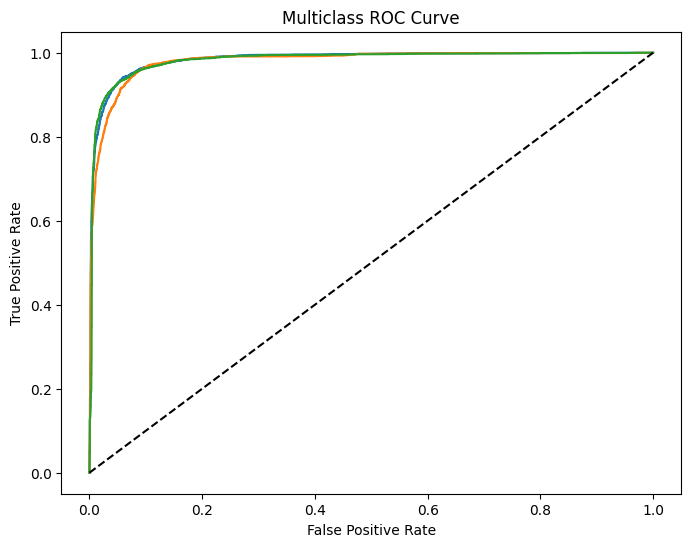

In [136]:
for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_train_proba[:, i])

# Plot each ROC curve
plt.figure(figsize=(8,6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f"Class {i} ROC curve")
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve")

In [48]:
import time
import numpy as np
from sklearn.metrics import f1_score

start_time = time.time()

# Train the model
model = SVC(probability=True, kernel='rbf', random_state=42)
model.fit(X_train_svm, y_train_svm)

end_time = time.time()
train_time = end_time - start_time

# Predict on training data
y_train_pred = model.predict(X_train_svm)

labels = le.classes_
f1_per_class = f1_score(y_train_svm, y_train_pred, average=None)

# Print F1 scores for Positive and Negative classes only
if 'Positive' in labels and 'Negative' in labels:
    pos_idx = np.where(labels == 'Positive')[0][0]
    neg_idx = np.where(labels == 'Negative')[0][0]

    print(f"F1 Score for Positive = {f1_per_class[pos_idx]:.4f}")
    print(f"F1 Score for Negative = {f1_per_class[neg_idx]:.4f}")
else:
    print("Positive and/or Negative class not found in label encoder classes.")

print(f"Training Time: {train_time:.2f} seconds")


F1 Score for Positive = 0.6833
F1 Score for Negative = 0.6600
Training Time: 71.86 seconds


##  Next Steps

1. **Hyperparameter Tuning with RandomizedSearchCV**  
   The current SVM model can be further improved by performing hyperparameter tuning. This includes:
   - Trying different **kernels** like `'rbf'`, `'poly'`, and `'linear'`.
   - Varying important parameters like **`C`** and **`gamma`**.
   - Using  **RandomizedSearchCV** to find the optimal combination for better performance and generalization.

2. **Compare with Other Models (Baseline vs Advanced)**  
   To ensure the best possible model, we can compare the tuned SVM with other classifiers:
   - **Baseline models** such as Logistic Regression.
   - **Advanced models** such as Random Forest and XGBoost.
   - All models should be trained on the **same balanced dataset** and evaluated using the **same metrics** (e.g., F1-score, AUC, confusion matrix) to ensure fair comparison.
